In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import logging
import h5py
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from math import sqrt
from itertools import product
import numba
import functools
import time

from mlpng.utils import *
from mlpng.generator import Generator
from mlpng.utils.utils import *
from mlpng.utils.plots import plot_cl, plot_map, plot_map_alm

import lenspyx
from lenspyx import utils_hp
import matplotlib.ticker as ticker

from joblib import Parallel, delayed
from scipy.interpolate import interp1d
from ksw.radial_functional import radial_func
from scipy.integrate import trapezoid
import numba

# from mlpng.bispectrum import (
#     compute_bispectrum_local,
#     compute_trispectrum,
#     tri,
#     compute_W,
#     compute_S,
# )
import vegas

from tqdm.auto import tqdm

2025-10-14 09:48:18.348885: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-14 09:48:19.274031: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-14 09:48:19.274103: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-14 09:48:19.491187: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-14 09:48:20.050035: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-14 09:48:20.062171: I tensorflow/core/platform/cpu_feature_guard.cc:1

# Get the unlensed gaussian Alms

This should be correct, notice we do not do any non-gaussian here due to just testing the lensing deflection field.

In [3]:
# generator = Generator(
#     [
#         "settings/n128.json",
#         "--nsims",
#         "1",
#         "--pols",
#         "T",
#         "--phi_scale",
#         "2.0",
#         "--shape",
#         "local",
#         "--no-noise",
#         # "--double_precision",
#     ]
# )

In [4]:
# pol_idxs = generator.pol_idxs()

# sims = [
#     hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
#     for _ in range(generator.nsims)
# ]
# sims = remove_mono_dipole(np.array(sims))
# alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

# plot_cl_alm(
#     generator,
#     alm_l,
#     title=r"Unlensed gaussian $C_{\ell}^{TT}$",
#     ylabel=r"$C_{\ell}^{TT}$",
#     show=True,
#     plot_camb=True,
# )
# plot_map_alm(
#     generator,
#     alm_l,
#     title=r"Unlensed gaussian $C_{\ell}^{TT}$",
#     zoom=True,
#     show=True,
# )

# Deflection Fields

Here we generate the deflection fields $d_{\ell m}$ for the lensing. We get the lensing potential power spectrum $C_{\ell}^{\phi\phi}$ from CAMB, and convert this to the deflection field by $d_{\ell m} = \sqrt{\ell(\ell+1)}C_{\ell}^{\phi\phi}$. This is per the lenspyx demo https://github.com/carronj/lenspyx/blob/master/examples/demo_lenspyx.ipynb , but I would appricate confirmation that the $C_{\ell}^{\phi\phi}$ is the correct one to use here.

To scale the lensing potential I am currently applying the scale to the $p_{lm}$ before converting to the harmoincs. This is disable right now as I am testing just a normal lensing potential, but does that look correct?

In [5]:
# # we use a buffer for the lmax to ensure we can compute the lensing potential without error
# lmax = generator.lmax + generator.lmax_buffer

# # our conversion factor = sqrt(l * (l + 1))
# fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

# # cl_phi is PP PT PE, we only want the phi phi part
# cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
#     lmax,
#     "muK",
#     raw_cl=True,
# )
# cl_phi = cl_phi[..., 0]

# # the weird factors here are to match plots from lewis
# # https://indico.cern.ch/event/218615/contributions/448794/attachments/353290/492159/Lewis.pdf page 11
# plot_cl(
#     generator,
#     cl_phi * fl**4 / 2 / np.pi,
#     title=r"Lensing potential $C_{\ell}^{\phi\phi}$",
#     ylabel=r"$(\ell (\ell + 1))^2 / 2 \pi\;C_{\ell}^{\phi\phi}$",
#     show=True,
#     scale=False,
#     plot_func=plt.loglog,
# )

In [6]:
# alm_phi = hp.synalm(
#     cl_phi,
#     lmax,
#     lmax,
#     new=True,
#     verbose=False,
# )
# alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

# plot_cl_alm(
#     generator,
#     alm_phi,
#     title="Lensing potential alm, $\phi_{lm}$",
#     ylabel=r"$\phi_{lm}$",
#     show=True,
#     # scale=False,
#     plot_func=plt.loglog,
# )
# plot_map_alm(generator, alm_phi, title="plm", zoom=True, show=True)

In [7]:
# # transform the lensing potential into spin-1 deflection field
# dlm = hp.almxfl(alm_phi, fl)

# plot_cl_alm(
#     generator,
#     dlm,
#     lmax=lmax,
#     title="Lensing deflection field alm",
#     ylabel=r"$d_{lm}$",
#     # scale=False
#     show=True,
#     plot_func=plt.loglog,
# )
# plot_map_alm(generator, dlm, title="$d_{lm}$", zoom=True, show=True)

here we get the lensed maps from the gaussian alm's using our $d_{lm}$s calculated previously. We only do a single T mode lenmap no matter the settings above for testing, this gives us the `alm_l[0, 0]` below which is dimensions `(sim, pol, data)`.

In [8]:
# lenmap = lenspyx.alm2lenmap(
#     alm_l,
#     dlm,
#     geometry=("healpix", {"nside": generator.nside}),
#     nthreads=generator.slurm.n_cpus,
# )
# lenmap = remove_mono_dipole(lenmap)

# plot_map(lenmap, title="Lensed map", zoom=True, show=True)

In [9]:
# unlen_map = hp.alm2map(
#     alm_l,
#     nside=generator.nside,
#     lmax=generator.lmax,
#     verbose=False,
# )
# unlen_map = remove_mono_dipole(unlen_map)

# plot_map(unlen_map, title="Unlensed map", zoom=True, show=True)
# plot_map(lenmap - unlen_map, title="Lensed - Unlensed map", zoom=True, show=True)

Here is where we caculate the error in our estimator for the lenses code. To get the $C_{\ell}$ used to get the $\text{icov}=C^{-1}$ used in the calculation I am using the lensed maps and using anafast to calculate the cls. With many maps I would average over the resulting cls. The issues here is a higher lensing potential will result in a lower variance which is not what we expect.

In [10]:
# cl_lens = hp.anafast(lenmap, use_pixel_weights=True)
# cl_lens[:2] = 0

# plot_cl(generator, cl_lens, title="Lensed C_l", show=True, plot_camb=True)

# plot_cl_vs(
#     generator,
#     generator.c_ell[0],
#     cl_lens,
#     title="Lensed vs Unlensed C_l",
#     ylabel=r"$C_{\ell}^{TT}$",
#     show=True,
#     # scale=False,
#     # plot_func=plt.plot,
# )

# plot_cl(
#     generator,
#     cl_lens / generator.c_ell,
#     title="Lensed C_l / Unlensed C_l",
#     ylabel=r"$\frac{C_{\ell}^{TT}}{C_{\ell}^{TT,unlensed}}$",
#     show=True,
#     scale=False,
#     plot_func=plt.plot,
# )

# plot_cl(
#     generator,
#     (cl_lens - generator.c_ell) / generator.c_ell,
#     title="(Lensed - Unlensed C_l) / Unlensed C_l",
#     ylabel=r"$\frac{C_{\ell}^{TT} - C_{\ell}^{TT,unlensed}}{C_{\ell}^{TT,unlensed}}$",
#     show=True,
#     scale=False,
#     plot_func=plt.plot,
# )

# Compute the fishers

Here we compute the fishers, this takes a very long time based on the nside used

In [11]:
# fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
# if len(generator.shapes) > 1:
#     marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
# else:
#     marg_likes = np.sqrt(1 / fisher_mat)

# print(f"Unlensed marginal likelihoods: {marg_likes}")

In [12]:
# lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
# lens_cls *= generator.phi_scale

# plot_cl_vs(generator, lens_cls, cl_lens, labels=["camb", "lens"], show=True)

In [13]:
# icov = 1 / lens_cls
# icov[: generator.lmin] = 0.0
# icov = np.array(icov)

# fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
# if len(generator.shapes) > 1:
#     marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
# else:
#     marg_likes_lens = np.sqrt(1 / fisher_mat)

# print(f"Marginal likelihoods: {marg_likes_lens}")
# print(f"diff: {marg_likes_lens - marg_likes}")

In [14]:
# diff = marg_likes_lens - marg_likes
# ratio = marg_likes_lens / marg_likes

# print("nside:", generator.nside)
# print(
#     f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
# )

# the big loop

Just do a big loop to get a table, will take a long time

In [15]:
# # disable a root logger error from CAMB
# logging.getLogger("root").setLevel(logging.ERROR)

# for phi in [1.0, 1.1, 2, 3, 5, 10, 30, 100]:
#     generator = Generator(
#         [
#             "settings/n64.json",
#             "--nsims",
#             "1",
#             "--pols",
#             "T",
#             "--phi_scale",
#             str(phi),
#             "--shape",
#             "local",
#             "--no-noise",
#             # "--double_precision",
#         ],
#         logging.ERROR,
#     )

#     pol_idxs = generator.pol_idxs()

#     sims = [
#         hp.synalm(generator.c_ell, lmax=generator.lmax, new=True)
#         for _ in range(generator.nsims)
#     ]
#     sims = remove_mono_dipole(np.array(sims))
#     alm_l = np.ascontiguousarray(sims)[0, 0]  # ensure contiguous memory

#     # we use a buffer for the lmax to ensure we can compute the lensing potential without error
#     lmax = generator.lmax + generator.lmax_buffer

#     # our conversion factor = sqrt(l * (l + 1))
#     fl = np.sqrt(np.arange(lmax + 1) * np.arange(1, lmax + 2))

#     # cl_phi is PP PT PE, we only want the phi phi part
#     cl_phi = generator.cosmo._camb_data.get_lens_potential_cls(
#         lmax,
#         "muK",
#         raw_cl=True,
#     )
#     cl_phi = cl_phi[..., 0]

#     alm_phi = hp.synalm(
#         cl_phi,
#         lmax,
#         lmax,
#         new=True,
#         verbose=False,
#     )
#     alm_phi *= generator.phi_scale  # scale the lensing potential by phi_scale

#     dlm = hp.almxfl(alm_phi, fl)

#     lenmap = lenspyx.alm2lenmap(
#         alm_l,
#         dlm,
#         geometry=("healpix", {"nside": generator.nside}),
#         nthreads=generator.slurm.n_cpus,
#     )
#     lenmap = remove_mono_dipole(lenmap)

#     lens_cls = generator.cosmo.c_ell["lensed_scalar"]["c_ell"][: generator.nell, 0]
#     # lens_cls *= generator.phi_scale

#     icov = 1 / lens_cls
#     icov[: generator.lmin] = 0.0
#     icov = np.array(icov)

#     fisher_mat = np.array(generator.compute_fisher_shapes(generator.shapes))
#     if len(generator.shapes) > 1:
#         marg_likes = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes = np.sqrt(1 / fisher_mat)

#     fisher_mat = generator.compute_fisher_shapes(generator.shapes, icov=icov)
#     if len(generator.shapes) > 1:
#         marg_likes_lens = np.sqrt(np.diag(np.linalg.inv(fisher_mat)))
#     else:
#         marg_likes_lens = np.sqrt(1 / fisher_mat)

#     diff = marg_likes_lens - marg_likes
#     ratio = marg_likes_lens / marg_likes

#     print(
#         f"| {generator.phi_scale} | {float(marg_likes)} | {float(marg_likes_lens)} | {float(diff)} | {float(ratio)} |"
#     )

# S/N test

We will determine the effects of gravitational lensing by calculating the reduction in the
estimator signal to noise when the weights derived by ignoring gravitational lensing are used.
This means that the weight defined in Eq. (25, W(l_1, l_2, l_3)) will always be evaluated using unlensed CMB
power spectra.

however the Gaussian and non-Gaussian six-point functions in Eqs. (24, <N^2>),
(28, delta<N^2>) will be evaluated with the lensed CMB power spectra when specified

In [153]:
generator = Generator(
    [
        "settings/n64.json",
        # "settings/babich.json",
        # "settings/cremin_plot.json",
        # "settings/elsner.json",
        "--nsims",
        "1",
        "--pols",
        "T",
        "--shape",
        "local",
    ]
)

c_ell = generator.c_ell[0]
c_ell_lens = generator.c_ell_lens[0]
cov = generator.cov[0]
cov_lens = generator.cov_lens[0]
cl_phi = generator.cl_phi
radii = generator.radii

LMAX = generator.lmax
print("LMAX:", LMAX)

14-Oct-25 10:13:00 - mlpng.core - DEBUG - Parsing CLI args: ['settings/n64.json', '--nsims', '1', '--pols', 'T', '--shape', 'local']
14-Oct-25 10:13:00 - mlpng.core - INFO - Loading settings from file 'settings/n64.json'
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Forcing setting 'nsims' to 1 due to CLI
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Forcing setting 'pols' to T due to CLI
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Forcing setting 'shapes' to ['local'] due to CLI
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.105e-09
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Overriding cosmo param 'ns' from 0.9624 to 0.965
14-Oct-25 10:13:00 - mlpng.core - DEBUG - Running with settings: 
{
  "cosmo_params": {
    "As": 2.105e-09,
    "ns": 0.965,
    "pivot_scalar": 0.05,
    "H0": 67.4,
    "ombh2": 0.0224,
    "omch2": 0.12,
    "tau": 0.054
  },
  "nsims": 1,
  "nside": 64,
  "pols": "T",
  "shapes": [
    "local"
  ]
}
14-Oct-25 10:13:00 - mlpng.core

14-Oct-25 10:13:16 - root - WARNING - power_spectra_from_transfer with non-linear lensing does not recalculate the non-linear correction
LMAX: 191


In [154]:
generator.cosmo.camb_params

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_both
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 469
 max_l_tensor = 600
 max_eta_k = 36000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.0224
 omch2 = 0.12
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.4
 TCMB = 2.7255
 YHe = 0.24586829360147697
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.965
   nrun =

In [155]:
generator.cosmo._camb_data.get_derived_params()

{'age': 13.792679254057639,
 'zstar': 1089.9001966996618,
 'rstar': 144.41754544470865,
 'thetastar': 1.0412204757287857,
 'DAstar': 13.870025495188797,
 'zdrag': 1060.0181111219742,
 'rdrag': 147.06788505507686,
 'kd': 0.14090015719848958,
 'thetad': 0.16075375848265225,
 'zeq': 3403.597599799277,
 'keq': 0.010387089573020654,
 'thetaeq': 0.813215565706187,
 'thetarseq': 0.4493384196365473}

total
unlensed_scalar
unlensed_total
lensed_scalar
tensor
lens_potential
(352, 4)


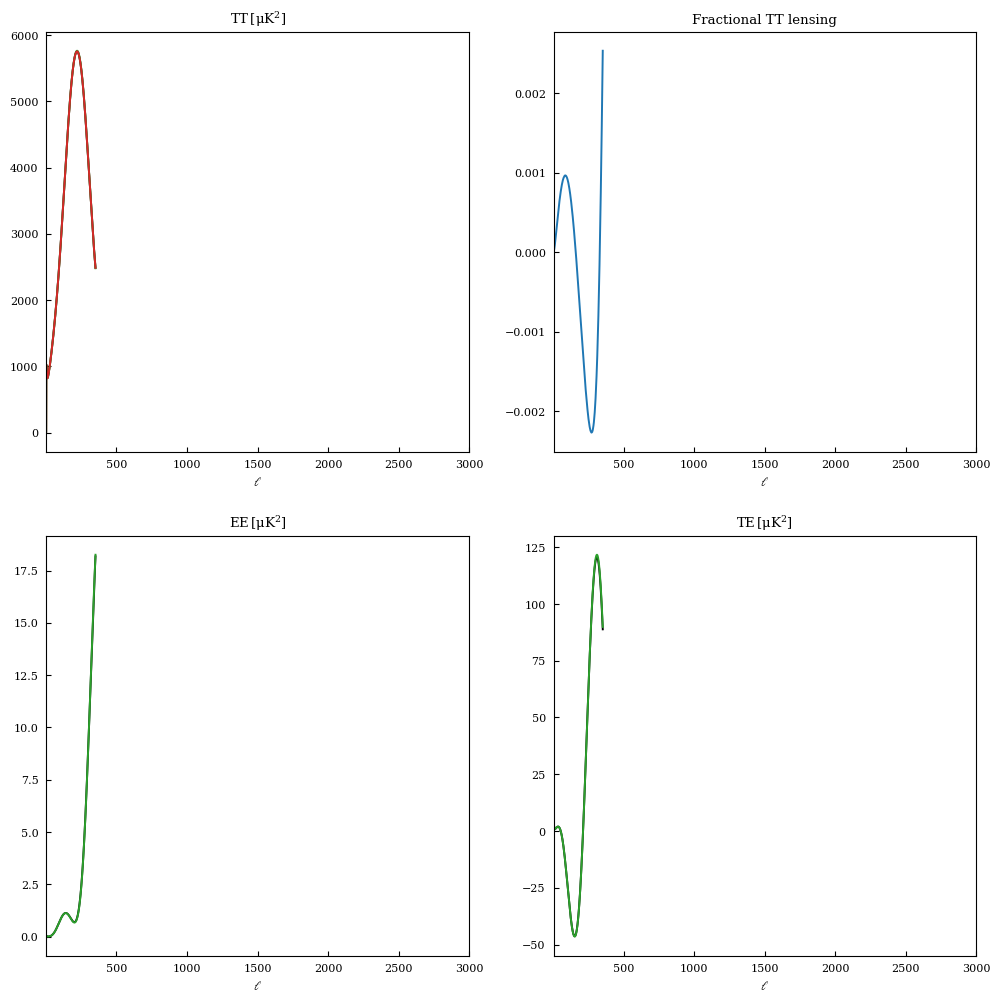

In [156]:
import camb

pars = camb.set_params(
    H0=67.5,
    ombh2=0.022,
    omch2=0.122,
    mnu=0.06,
    omk=0,
    tau=0.06,
    As=2e-9,
    ns=0.965,
    halofit_version="mead",
    lmax=3000,
)

powers = generator.cosmo._camb_data.get_cmb_power_spectra(CMB_unit="muK")
for name in powers:
    print(name)

# plot the total lensed CMB power spectra versus unlensed, and fractional difference
totCL = powers["total"]
unlensedCL = powers["unlensed_scalar"]
lensedCL = powers["lensed_scalar"]
print(totCL.shape)
# Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
# The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
ax[0, 0].plot(ls, totCL[:, 0], color="k")
ax[0, 0].plot(ls, unlensedCL[:, 0], color="C2")
ax[0, 0].plot(ls, lensedCL[:, 0], color="C3")
ax[0, 0].set_title(r"$TT\, [\mu K^2]$")
ax[0, 1].plot(ls[2:], 1 - unlensedCL[2:, 0] / totCL[2:, 0])
ax[0, 1].set_title(r"Fractional TT lensing")
ax[1, 0].plot(ls, totCL[:, 1], color="k")
ax[1, 0].plot(ls, unlensedCL[:, 1], color="C2")
ax[1, 0].set_title(r"$EE\, [\mu K^2]$")
ax[1, 1].plot(ls, totCL[:, 3], color="k")
ax[1, 1].plot(ls, unlensedCL[:, 3], color="C2")
ax[1, 1].set_title(r"$TE\, [\mu K^2]$")
for ax in ax.reshape(-1):
    ax.set_xlim([2, 3000])
    ax.set_xlabel(r"$\ell$")

## Small $C_{ell}$ and $C^\phi$ check

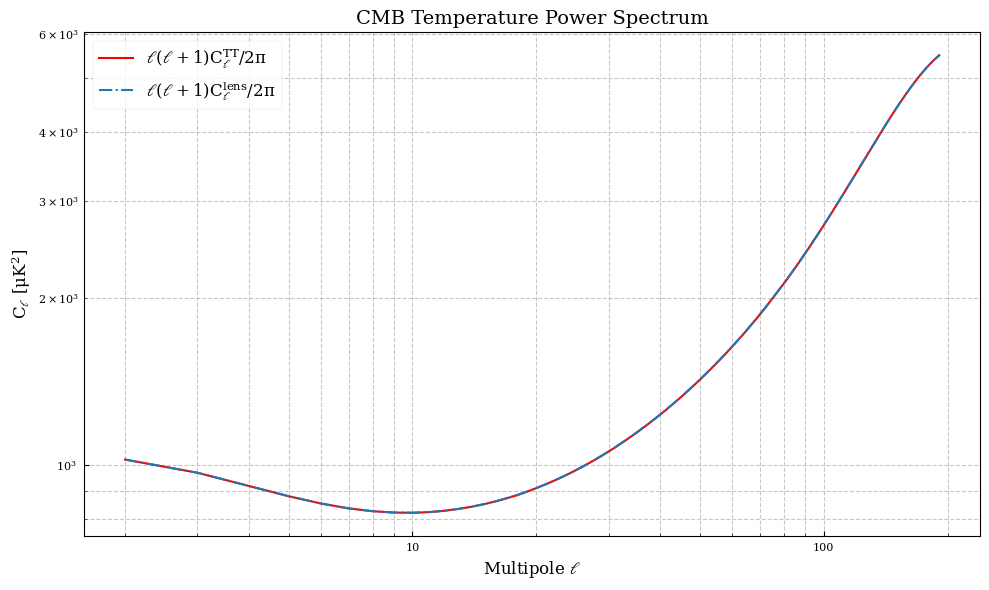

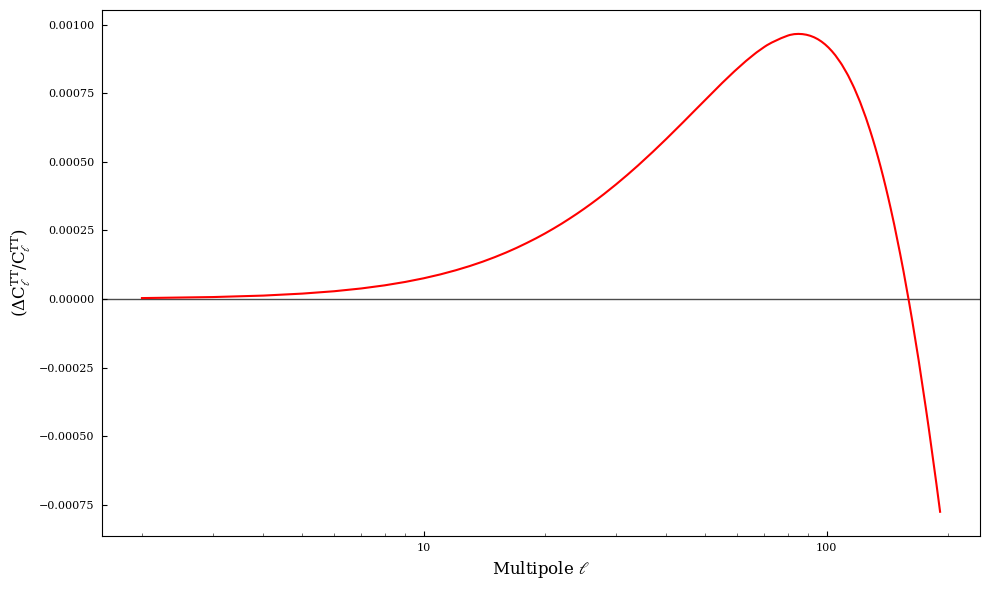

In [157]:
fig, ax = plt.subplots(figsize=(10, 6))

scaled_c_ell = np.array(
    [ell * (ell + 1) * c_ell[ell] / (2 * np.pi) for ell in range(2, len(c_ell))]
)
scaled_c_ell_lens = np.array(
    [ell * (ell + 1) * c_ell_lens[ell] / (2 * np.pi) for ell in range(2, len(c_ell))]
)
ax.loglog(
    range(2, len(c_ell)),
    scaled_c_ell,
    "r-",
    lw=1.5,
    label=r"$\ell(\ell+1)C_{\ell}^{TT}/2\pi$",
)
ax.loglog(
    range(2, len(c_ell)),
    scaled_c_ell_lens,
    "-.",
    lw=1.5,
    label=r"$\ell(\ell+1)C_{\ell}^{lens}/2\pi$",
)

# Formatting
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$C_{\ell}$ [$\mu$K$^2$]", fontsize=12)
ax.set_title("CMB Temperature Power Spectrum", fontsize=14)
ax.grid(which="both", linestyle="--", alpha=0.7)
ax.legend(fontsize=12)

# Adjust x-axis ticks to be more readable
# ax.set_xticks([2, 10, 100, 500, 1000])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

ax.semilogx(
    range(2, len(c_ell)),
    ((scaled_c_ell_lens - scaled_c_ell) / scaled_c_ell),
    "r-",
    lw=1.5,
)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
plt.axhline(y=0, color="k", linestyle="-", linewidth=1, alpha=0.7, zorder=1)
plt.xlabel(r"Multipole $\ell$", fontsize=12)
plt.ylabel(r"$(\Delta C_{\ell}^{TT} / C_{\ell}^{TT})$", fontsize=12)
plt.tight_layout()
plt.show()

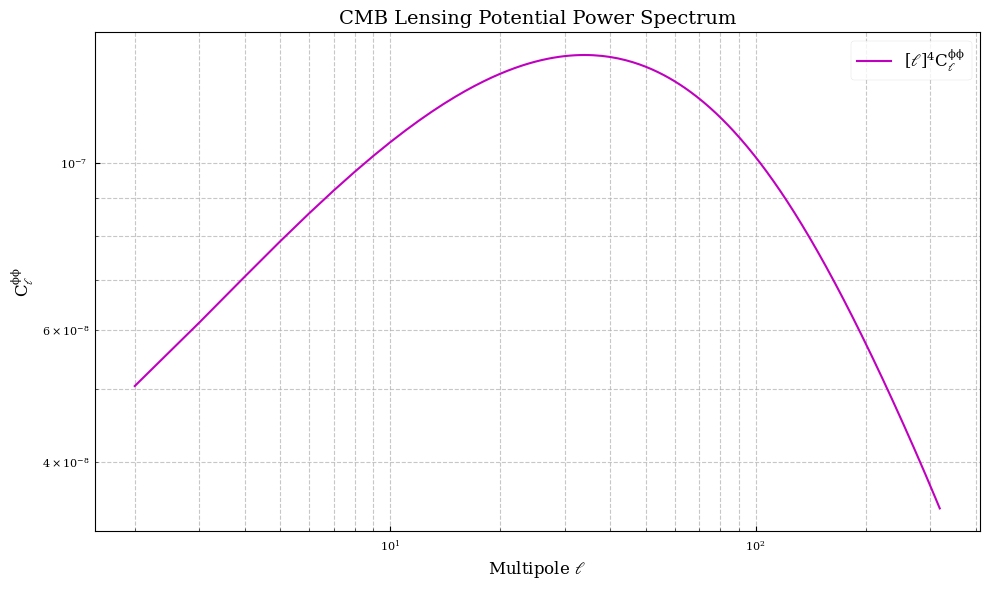

In [158]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot lensing potential with log-y scaling
ells = np.arange(len(cl_phi))
# ax.semilogy(ells, cl_phi, "g-", lw=1.5, label=r"Lensing potential $C_\ell^{\phi\phi}$")

fl = (ells * (ells + 1)) ** 2
scaled_cl_phi = cl_phi * fl / 2 / np.pi
ax.loglog(
    ells[2:],
    scaled_cl_phi[2:],
    "m-",
    lw=1.5,
    label=r"$[\ell]^4 C_\ell^{\phi\phi}$",
)
# Formatting
ax.set_xlabel(r"Multipole $\ell$", fontsize=12)
ax.set_ylabel(r"$C_\ell^{\phi\phi}$", fontsize=12)
ax.set_title("CMB Lensing Potential Power Spectrum", fontsize=14)
ax.grid(which="both", linestyle="--", alpha=0.7)
ax.legend(fontsize=12)

# Set x-axis range to start from ℓ=2
# ax.set_xlim(2, len(cl_phi) - 1)

# Adjust x-axis ticks to be more readable
# ax.set_xticks([2, 10, 100, 500, 1000])
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

plt.tight_layout()
plt.show()

## $\alpha$ and $\beta$ calculation

In [159]:
pol_idxs = generator.pol_idxs()
transfer = generator.cosmo.transfer

# get the transfer functions with tr_ell_k being \Delta_\ell(k)
tr_ells = transfer["ells"]
tr_k = transfer["k"]
tr_ell_k = transfer["tr_ell_k"]  # this is T, E, PHI
tr_ell_k = tr_ell_k[..., pol_idxs]

# camb returns transfers in zeta, need to convert to phi
tr_ell_k *= 5 / 3

# this will be the f(k) value to be placed in the radial function
# first will be for alpha_ell, second will be beta_ell
# see komatsu 2003 eq 5 and 6
f_k = np.ones((len(tr_k), 2), dtype=generator.r_dtype)

# we need to multiply the f_k by the delta_phi term, and convert from k^2 to k^-1
# see creminelii 2006, eq 16
# for delta_phi = A: (taken from adri's ksw)
# Planck defines A as <phi_k1 phi_k2> = (2pi)^3 delta(k12) A / k^3.
# CAMB defines As as <zeta_k2 zeta_k2> = (2pi)^3 delta(k12) 2 * pi^2 As / k^3.
# So A = (3/5)^2 * 2 * pi^2 As.
Pk = generator.cosmo.camb_params.primordial_power(tr_k, 0)
delta_phi = 2 * np.pi**2 * Pk * (3 / 5) ** 2

# prefactor = np.sqrt((ells + 2) * (ells + 1) * ells * (ells - 1))
# tr.delta_p_l_k[1, ...] *= prefactor[:, np.newaxis]
# # Scale with CMB temperature in uK.
# tr.delta_p_l_k *= self.camb_params.TCMB * 1e6
# prefactor = np.sqrt((tr_ells + 2) * (tr_ells + 1) * tr_ells * (tr_ells - 1))[
#     :, None
# ]
# tr_ell_k[..., 1] /= prefactor
# tr_ell_k /= generator.cosmo.camb_params.TCMB * 1e6

ns = generator.cosmo_params["ns"]
f_k[:, 1] = delta_phi * tr_k ** (-3)  # (ns - 4)
rad = radial_func(f_k, tr_ell_k, tr_k, generator.radii, tr_ells)

alpha_ell = rad[..., 0, 0]
alpha_l = interp1d(
    tr_ells,
    alpha_ell,
    kind="cubic",
    axis=1,
    bounds_error=False,
    fill_value=0,
)(
    generator.ells
)  # [..., 0]

beta_ell = rad[..., 0, 1]
beta_l = interp1d(
    tr_ells,
    beta_ell,
    kind="cubic",
    axis=1,
    bounds_error=False,
    fill_value=0,
)(
    generator.ells
)  # [..., 0]

targets [Mpc]: [13650.0, 13731.0, 13812, 13893.0, 13974.0]
Wanted 13650.0 got 13650.666666666668
Wanted 13731.0 got 13725.333333333334
Wanted 13812 got 13812.0
Wanted 13893.0 got 13892.0
Wanted 13974.0 got 13974.0


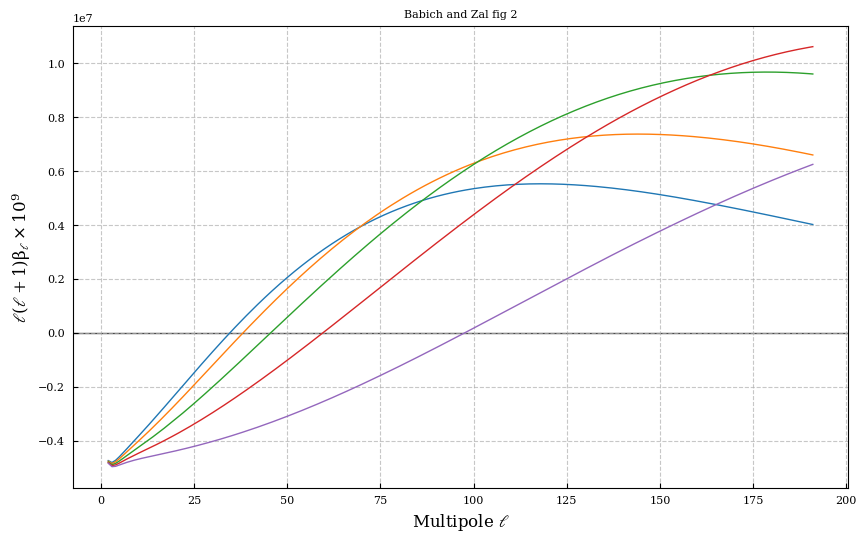

targets [Mpc]: [13650.0, 13731.0, 13812, 13893.0, 13974.0]
Wanted 13650.0 got 13650.666666666668
Wanted 13731.0 got 13725.333333333334
Wanted 13812 got 13812.0
Wanted 13893.0 got 13892.0
Wanted 13974.0 got 13974.0


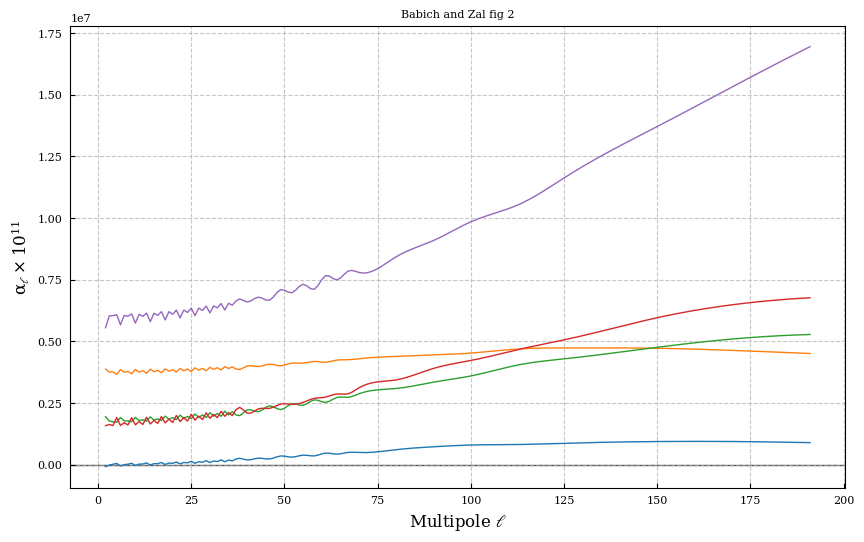

In [160]:
def plot_alpha_beta_comparison(transfer, scale, mult_ells=False, a_or_b=""):

    # tau_0 = 46200 Myr # current
    # tau_r = 911 Myr  # recombination
    # R_d = c * (tau_0 - tau_r) = 13876 Mpc # comoving distance to the sls

    tau_0 = 14082  # Mpc
    tau_r = 270
    targets = [(tau_0 - k * tau_r) for k in [1.6, 1.3, 1, 0.7, 0.4]]
    # targets = [(tau_0 - k * tau_r)*3.26 for k in np.arange(0.1, 4.0, 0.1)]
    print("targets [Mpc]:", targets)

    lmax = 500
    r_idxs = []
    # for target in [13988, 13876, 13765]:
    for target in targets:
        r_idxs.append(np.argmin(np.abs(generator.radii - target)))
        print(f"Wanted {target} got {generator.radii[r_idxs[-1]]}")

    plt.figure(figsize=(10, 6))
    for i, idx in enumerate(r_idxs):
        actual_r = generator.radii[idx]

        ells_plot = generator.ells
        ells_plot_slice = ells_plot[2:lmax]
        trans_slice = transfer[idx, 2:lmax]

        if mult_ells:
            scaling_factor = ells_plot_slice * (ells_plot_slice + 1) * 10**scale
        else:
            scaling_factor = 10**scale
        scaled_trans = scaling_factor * trans_slice

        plt.plot(
            ells_plot_slice,
            scaled_trans,
            # color=color,
            linewidth=1,
            # linestyle=linestyles[i],
            label=f"r={actual_r:.1f}",
        )

    plt.axhline(y=0, color="k", linestyle="-", linewidth=1, alpha=0.7, zorder=1)

    label = rf"${a_or_b}_\ell \times 10^{{{scale}}}$"
    if mult_ells:
        label = rf"$\ell(\ell+1){{{a_or_b}}}_\ell \times 10^{{{scale}}}$"

    # Formatting
    plt.xlabel(r"Multipole $\ell$", fontsize=12)
    plt.ylabel(label, fontsize=12)
    plt.title(r"Babich and Zal fig 2", fontsize=8)
    plt.grid(which="both", linestyle="--", alpha=0.7)
    # plt.legend(fontsize=11)
    # plt.gca().set_xticks([2, 10, 100, 1000, 10000])
    # plt.gca().get_xaxis().set_major_formatter(plt.ScalarFormatter())
    # plt.tight_layout()
    plt.show()


# Generate the corrected plot
plot_alpha_beta_comparison(beta_l, 9, True, r"\beta")
plot_alpha_beta_comparison(alpha_l, 11, a_or_b=r"\alpha")

## Bispectrum and Trispectrum calculations

We do 2 diffrent trispectrum calcaltions here, one from zal and one from ....

In [161]:
@numba.njit(nogil=True, fastmath=False)
def numba_trapezoid(y, x):
    n = len(x)
    integral = 0.0
    for i in range(1, n):
        integral += (x[i] - x[i - 1]) * (y[i] + y[i - 1]) / 2.0

    return integral


@numba.njit(nogil=True, fastmath=False)
def compute_bispectrum_local(alpha, beta, l1, l2, l3, rs):
    integrand = (
        rs
        * rs
        * (
            beta[l3] * beta[l2] * alpha[l1]
            + beta[l1] * beta[l3] * alpha[l2]
            + beta[l2] * beta[l1] * alpha[l3]
        )
    )

    return 6.0 / 5.0 * numba_trapezoid(integrand, x=rs)

In [162]:
@numba.njit(nogil=True, fastmath=False)
def tri_single_zal(
    lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1
):
    l13_0 = l1_0 + l3_0
    l13_1 = l1_1 + l3_1

    l14_0 = l1_0 + l4_0
    l14_1 = l1_1 + l4_1

    # lm = 2*lmax
    # if not (
    #     -lm <= l13_0 <= lm
    #     and -lm <= l13_1 <= lm
    #     and -lm <= l14_0 <= lm
    #     and -lm <= l14_1 <= lm
    # ):
    #     return 0.0

    l1_mag = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2_mag = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l13_mag = int(round(sqrt(l13_0 * l13_0 + l13_1 * l13_1)))
    l14_mag = int(round(sqrt(l14_0 * l14_0 + l14_1 * l14_1)))

    if not (
        2 < l1_mag <= lmax
        and 2 < l2_mag <= lmax
        and 2 < l13_mag <= lmax
        and 2 < l14_mag <= lmax
    ):
        return 0.0

    l13_dot_l1 = l13_0 * l1_0 + l13_1 * l1_1
    l13_dot_l2 = l13_0 * l2_0 + l13_1 * l2_1
    l14_dot_l1 = l14_0 * l1_0 + l14_1 * l1_1
    l14_dot_l2 = l14_0 * l2_0 + l14_1 * l2_1

    return (
        c_ell[l1_mag]
        * c_ell[l2_mag]
        * (
            l13_dot_l1 * l13_dot_l2 * c_ell_phi[l13_mag]
            + l14_dot_l1 * l14_dot_l2 * c_ell_phi[l14_mag]
        )
    )


@numba.njit(nogil=True, fastmath=False)
def tri_zal(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    total = 0.0
    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1
    )
    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1
    )
    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1
    )

    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1
    )
    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1
    )

    total += tri_single_zal(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1, l2_0, l2_1
    )
    return total

In [163]:
@numba.njit(nogil=True, fastmath=False)
def tri_single(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    l13_0 = l1_0 + l3_0
    l13_1 = l1_1 + l3_1
    l24_0 = l2_0 + l4_0
    l24_1 = l2_1 + l4_1

    l13_mag = int(round(sqrt(l13_0 * l13_0 + l13_1 * l13_1)))
    l3_mag = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    l4_mag = int(round(sqrt(l4_0 * l4_0 + l4_1 * l4_1)))

    if not (2 < l3_mag <= lmax and 2 < l4_mag <= lmax and 2 < l13_mag <= lmax):
        return 0.0

    l13_3 = l13_0 * l3_0 + l13_1 * l3_1
    l24_4 = l24_0 * l4_0 + l24_1 * l4_1
    return c_ell_phi[l13_mag] * c_ell[l3_mag] * c_ell[l4_mag] * l13_3 * l24_4


@numba.njit(nogil=True, fastmath=False)
def tri(lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1):
    value = 0.0
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1, l2_0, l2_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l3_0, l3_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l1_0, l1_1, l4_0, l4_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l2_0, l2_1, l4_0, l4_1, l3_0, l3_1, l1_0, l1_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l1_0, l1_1, l2_0, l2_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l1_0, l1_1, l4_0, l4_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l2_0, l2_1, l1_0, l1_1, l4_0, l4_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l2_0, l2_1, l4_0, l4_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l4_0, l4_1, l1_0, l1_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l3_0, l3_1, l4_0, l4_1, l2_0, l2_1, l1_0, l1_1
    )

    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l1_0, l1_1, l2_0, l2_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l1_0, l1_1, l3_0, l3_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l2_0, l2_1, l1_0, l1_1, l3_0, l3_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l2_0, l2_1, l3_0, l3_1, l1_0, l1_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l3_0, l3_1, l1_0, l1_1, l2_0, l2_1
    )
    value += tri_single(
        lmax, c_ell, c_ell_phi, l4_0, l4_1, l3_0, l3_1, l2_0, l2_1, l1_0, l1_1
    )

    return value / 2.0

In [164]:
# def random_unit_vector():
#     """Generate a random 2D unit vector."""
#     theta = np.random.uniform(0, 2 * np.pi)
#     return np.array([np.cos(theta), np.sin(theta)])


# def test_trispectrum_functions(c_ell, cl_phi, num_tests=1000, lmin=2, lmax=LMAX):
#     results_tri = []
#     results_compute = []
#     ell_values = []

#     # Ensure arrays are long enough
#     assert (
#         len(c_ell) > lmax and len(cl_phi) > lmax
#     ), "Power spectra must extend beyond lmax"

#     for i in range(num_tests):
#         # Generate random ell magnitudes
#         ell1 = np.random.randint(lmin, lmax)
#         ell2 = np.random.randint(lmin, lmax)
#         ell3 = np.random.randint(lmin, lmax)

#         # Create random vectors with these magnitudes
#         v1 = random_unit_vector() * ell1
#         v2 = random_unit_vector() * ell2
#         v3 = random_unit_vector() * ell3
#         v4 = -(v1 + v2 + v3)
#         ell4 = int(round(np.sqrt(v4.dot(v4))))

#         if any([not 2 < x <= lmax for x in [ell1, ell2, ell3, ell4]]):
#             continue

#         tri_result = tri(
#             lmax, c_ell, cl_phi, v1[0], v1[1], v2[0], v2[1], v3[0], v3[1], v4[0], v4[1]
#         )
#         compute_result = -tri_zal(
#             lmax, c_ell, cl_phi, v1[0], v1[1], v2[0], v2[1], v3[0], v3[1], v4[0], v4[1]
#         )

#         if tri_result == 0.0 or compute_result == 0.0:
#             continue

#         results_tri.append(tri_result)
#         results_compute.append(compute_result)
#         ell_values.append((ell1, ell2, ell3, ell4))

#         # ratio = np.abs(tri_result / compute_result)
#         # if 1 - 1e-4 > ratio or ratio > 1 + 1e-4:
#         #     print("Large Discrepancy found...")
#         #     print(f"Test {i + 1}:")
#         #     print(
#         #         f"  ℓ values: {v1} / {ell1}, {v2} / {ell2}, {v3} / {ell3}, {v4} / {ell4}"
#         #     )
#         #     print(f"  even parity: {(ell1 + ell2 + ell3 + ell4) % 2 == 0}")
#         #     print(f"  tri result: {tri_result}")
#         #     print(f"  compute_trispectrum result: {compute_result}")
#         #     print(
#         #         f"  ratio: {tri_result / compute_result if compute_result != 0 else 'inf'}"
#         #     )
#         #     print()

#     # Plot comparison
#     print(len(results_tri), "tests completed.")
#     plt.figure(figsize=(10, 6))
#     plt.semilogy(
#         range(len(results_tri)),
#         [
#             np.abs(r1 / r2) if r2 != 0 else np.nan
#             for r1, r2 in zip(results_tri, results_compute)
#         ],
#     )
#     plt.axhline(y=1.0, color="r", linestyle="-")
#     plt.xlabel("Test number")
#     plt.ylabel("tri / compute_trispectrum ratio")
#     plt.title("Comparison of trispectrum calculation methods")
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

#     return ell_values, results_tri, results_compute


# test_results = test_trispectrum_functions(c_ell, cl_phi, num_tests=10000)

## Main S/N functions

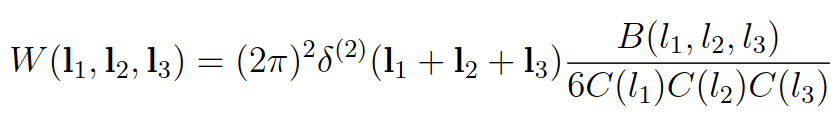

In [165]:
@numba.njit(nogil=True, fastmath=False)
def compute_W(l1, l2, l3, c_ell, radii, alpha, beta):
    C6 = 6.0 * c_ell[l1] * c_ell[l2] * c_ell[l3]
    B = compute_bispectrum_local(alpha, beta, l1, l2, l3, radii)
    return 4 * np.pi * np.pi * B / C6

#### S calculation

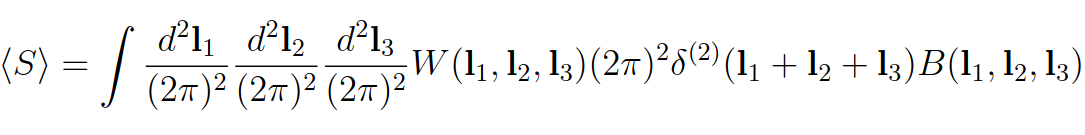

In [166]:
@numba.njit(nogil=True, fastmath=False)
def s_integrand_scalar(x, lmax, c_ell, alpha, beta, radii):
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1

    l1_mag = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2_mag = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3_mag = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))

    if not (2 < l1_mag <= lmax and 2 < l2_mag <= lmax and 2 < l3_mag <= lmax):
        return 0.0

    W = compute_W(l1_mag, l2_mag, l3_mag, c_ell, radii, alpha, beta)
    B = compute_bispectrum_local(alpha, beta, l1_mag, l2_mag, l3_mag, radii)
    return W * B


@numba.njit(parallel=True, nogil=True, fastmath=False)
def s_integrand_batch(x_batch, lmax, c_ell, alpha, beta, radii):
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float64)
    for i in numba.prange(n):
        out[i] = s_integrand_scalar(x_batch[i], lmax, c_ell, alpha, beta, radii)
    return out


class SIntegrandNumbaVec(vegas.LBatchIntegrand):
    def __init__(self, lmax, c_ell, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        return s_integrand_batch(
            x,
            self.lmax,
            self.c_ell,
            self.alpha,
            self.beta,
            self.radii,
        )


def compute_S_numba_vec(
    c_ell,
    lmax=LMAX,
    neval=5e6,
    nitn=(10, 10),
    summary=False,
    **kwargs,
):
    integrand = SIntegrandNumbaVec(
        lmax,
        c_ell,
        alpha_l.T,
        beta_l.T,
        generator.radii,
    )

    integ = vegas.Integrator([[-lmax, lmax]] * 4)
    integ(
        integrand,
        nitn=nitn[0],
        neval=neval,
    )
    result = integ(
        integrand,
        nitn=nitn[1],
        neval=neval,
        **kwargs,
    )

    if summary:
        print(result.summary(), flush=True)

    return result.mean / (2 * np.pi) ** 4 / np.pi

### N^2 Integrand

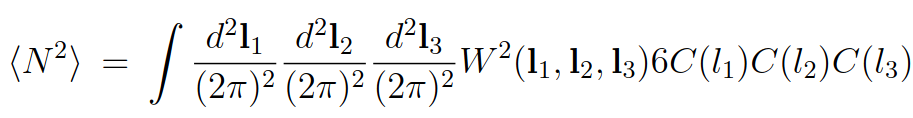

In [167]:
@numba.njit(nogil=True, fastmath=False)
def n2_integrand_scalar(x, lmax, c_ell, c_ell_lens, alpha, beta, radii):
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1

    lm = lmax
    if not (-lm <= l3_0 <= lm and -lm <= l3_1 <= lm):
        return 0.0

    l1 = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2 = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3 = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))

    if not (2 < l1 <= lmax and 2 < l2 <= lmax and 2 < l3 <= lmax):
        return 0.0

    cl = c_ell_lens if c_ell_lens is not None else c_ell
    C6 = 6.0 * cl[l1] * cl[l2] * cl[l3]
    W = compute_W(l1, l2, l3, c_ell, radii, alpha, beta)

    return W * W * C6


@numba.njit(parallel=True, nogil=True, fastmath=False)
def n2_integrand_batch(x_batch, lmax, c_ell, c_ell_lens, alpha, beta, radii):
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float64)

    for i in numba.prange(n):
        out[i] = n2_integrand_scalar(
            x_batch[i],
            lmax,
            c_ell,
            c_ell_lens,
            alpha,
            beta,
            radii,
        )
    return out


class N2IntegrandNumbaVec(vegas.LBatchIntegrand):
    def __init__(self, lmax, c_ell, c_ell_lens, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.c_ell_lens = c_ell_lens
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        return n2_integrand_batch(
            x,
            self.lmax,
            self.c_ell,
            self.c_ell_lens,
            self.alpha,
            self.beta,
            self.radii,
        )


def compute_N2_numba_vec(
    c_ell,
    c_ell_lens=None,
    lmax=LMAX,
    neval=1e7,
    nitn=(10, 10),
    summary=False,
    integ=None,
    **kwargs,
):
    integrand = N2IntegrandNumbaVec(
        lmax,
        c_ell,
        c_ell_lens,
        alpha_l.T,
        beta_l.T,
        generator.radii,
    )

    if integ is None:
        integ = vegas.Integrator([[-lmax, lmax]] * 4)
        integ(integrand, nitn=nitn[0], neval=neval)

    result = integ(integrand, nitn=nitn[1], neval=neval, **kwargs)

    res = result.mean / (2 * np.pi) ** 6 / np.pi

    if summary:
        print(result.summary(), flush=True)
        print(res)
        # integ.map.show_grid(100)

    return res, integ
    # return result.mean / (2 * np.pi) ** 6, integ

#### neval test

looks like 1e6 is good enough

In [168]:
# for n in [1e5, 1e6, 5e6, 1e7]:  # , 1e8]:
#     start = time.time()
#     val = compute_N2_numba_vec(c_ell, neval=n, summary=True)
#     run_time = time.time() - start
#     print(f"{n=}, {val=}, {run_time=}")

# total = 0
# integ = None
# for _ in range(10):
#     val, integ = compute_N2_numba_vec(c_ell, neval=1e7, summary=True, integ=integ)
#     print(val)
#     total += val
# print(total / 10)

### delta N^2 Integrand

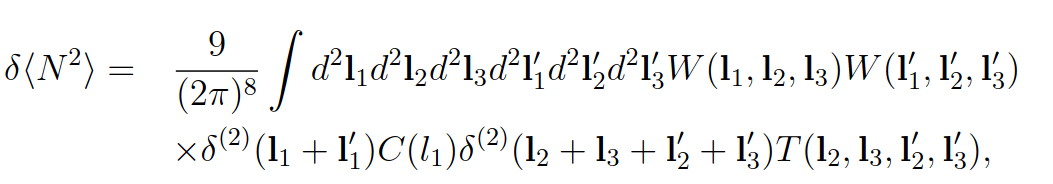

In [169]:
@numba.njit(nogil=True, fastmath=False)
def delta_n2_integrand_scalar(x, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
    l1_0, l1_1 = x[0], x[1]
    l2_0, l2_1 = x[2], x[3]
    lp2_0, lp2_1 = x[4], x[5]

    l3_0, l3_1 = -l1_0 - l2_0, -l1_1 - l2_1
    lp1_0, lp1_1 = -l1_0, -l1_1
    lp3_0, lp3_1 = -l2_0 - l3_0 - lp2_0, -l2_1 - l3_1 - lp2_1

    lm = lmax
    if not (
        -lm <= l3_0 <= lm
        and -lm <= l3_1 <= lm
        and -lm <= lp1_0 <= lm
        and -lm <= lp1_1 <= lm
        and -lm <= lp3_0 <= lm
        and -lm <= lp3_1 <= lm
    ):
        return 0.0

    l1 = int(round(sqrt(l1_0 * l1_0 + l1_1 * l1_1)))
    l2 = int(round(sqrt(l2_0 * l2_0 + l2_1 * l2_1)))
    l3 = int(round(sqrt(l3_0 * l3_0 + l3_1 * l3_1)))
    lp1 = int(round(sqrt(lp1_0 * lp1_0 + lp1_1 * lp1_1)))
    lp2 = int(round(sqrt(lp2_0 * lp2_0 + lp2_1 * lp2_1)))
    lp3 = int(round(sqrt(lp3_0 * lp3_0 + lp3_1 * lp3_1)))

    if not (
        2 < l1 <= lmax
        and 2 < l2 <= lmax
        and 2 < l3 <= lmax
        and 2 < lp1 <= lmax
        and 2 < lp2 <= lmax
        and 2 < lp3 <= lmax
    ):
        return 0.0

    W = compute_W(l1, l2, l3, c_ell, radii, alpha, beta)
    Wp = compute_W(lp1, lp2, lp3, c_ell, radii, alpha, beta)
    T = tri(lmax, c_ell, cl_phi, l2_0, l2_1, l3_0, l3_1, lp2_0, lp2_1, lp3_0, lp3_1)
    return W * Wp * c_ell_lens[l1] * T


@numba.njit(parallel=True, nogil=True, fastmath=False)
def delta_n2_integrand_batch(
    x_batch, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii
):
    n = x_batch.shape[0]
    out = np.zeros(n, dtype=np.float64)

    for i in numba.prange(n):
        out[i] = delta_n2_integrand_scalar(
            x_batch[i],
            lmax,
            c_ell,
            c_ell_lens,
            cl_phi,
            alpha,
            beta,
            radii,
        )

    return out


class DeltaN2IntegrandNumbaVec(vegas.LBatchIntegrand):
    def __init__(self, lmax, c_ell, c_ell_lens, cl_phi, alpha, beta, radii):
        self.lmax = lmax
        self.c_ell = c_ell
        self.c_ell_lens = c_ell_lens
        self.cl_phi = cl_phi
        self.alpha = alpha
        self.beta = beta
        self.radii = radii

    def __call__(self, x):
        return delta_n2_integrand_batch(
            x,
            self.lmax,
            self.c_ell,
            self.c_ell_lens,
            self.cl_phi,
            self.alpha,
            self.beta,
            self.radii,
        )


def compute_delta_N2_numba_vec(
    lmax=LMAX,
    neval=1e7,
    nitn=(10, 10),
    summary=False,
    **kwargs,
):
    integrand = DeltaN2IntegrandNumbaVec(
        lmax,
        c_ell,
        c_ell_lens,
        cl_phi,
        alpha_l.T,
        beta_l.T,
        generator.radii,
    )

    integ = vegas.Integrator([[-lmax, lmax]] * 6, neval=neval)
    integ(integrand, nitn=nitn[0], neval=neval)
    result = integ(integrand, nitn=nitn[1], neval=neval, **kwargs)

    if summary:
        print(result.summary(), flush=True)
        # integ.map.show_grid(100)

    return 9.0 / (2 * np.pi) ** 8 * result.mean / np.pi

In [170]:
# for n in [5e6, 1e7, 5e7, 1e8]:
#     start = time.time()
#     val = compute_delta_N2_numba_vec(neval=n, summary=True)
#     run_time = time.time() - start
#     print(f"{n=}, {val=}, {run_time=}")

### (S / n)^2 Integrand

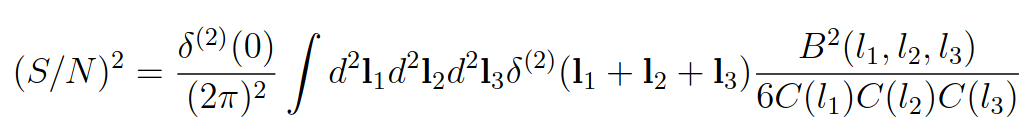

In [171]:
# class SN2Integrand:
#     def __init__(self, lmax, c_ell, alpha, beta, radii):
#         self.lmax = lmax
#         self.c_ell = c_ell
#         self.alpha = alpha
#         self.beta = beta
#         self.radii = radii

#     def __call__(self, x):
#         l1 = np.array([x[0], x[1]])
#         l2 = np.array([x[2], x[3]])
#         l3 = -l1 - l2  # l3 is a vector

#         # get the magnitudes as ints
#         l1_mag = int(round(np.sqrt(l1.dot(l1))))
#         l2_mag = int(round(np.sqrt(l2.dot(l2))))
#         l3_mag = int(round(np.sqrt(l3.dot(l3))))

#         for x in [l1_mag, l2_mag, l3_mag]:
#             if not 2 <= x <= self.lmax:
#                 return 0.0

#         B = compute_bispectrum_local(
#             self.alpha, self.beta, l1_mag, l2_mag, l3_mag, self.radii
#         )
#         C6 = 6 * self.c_ell[l1_mag] * self.c_ell[l2_mag] * self.c_ell[l3_mag]
#         return B**2 / C6


# def compute_SN2(c_ell, lmax=LMAX, neval=1e4, summary=False):
#     integrand = SN2Integrand(lmax, c_ell, alpha_l.T, beta_l.T, generator.radii)
#     integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

#     integ(
#         integrand,
#         nitn=10,
#         neval=neval,
#         nproc=generator.slurm.n_cpus,
#     )
#     result = integ(
#         integrand,
#         nitn=10,
#         neval=neval,
#         nproc=generator.slurm.n_cpus,
#     )

#     if summary:
#         print(result.summary(), flush=True)

#     # delta^(2)(0) = f_sky / pi, f_sky = 1
#     return result.mean / np.pi / (2 * np.pi) ** 2

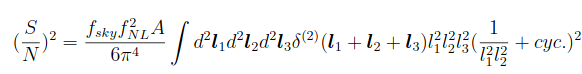

In [172]:
# class SN2NTIntegrand:
#     def __init__(self, lmax, c_ell, alpha, beta, radii):
#         self.lmax = lmax
#         self.c_ell = c_ell
#         self.alpha = alpha
#         self.beta = beta
#         self.radii = radii

#     def __call__(self, x):
#         l1 = np.array([x[0], x[1]])
#         l2 = np.array([x[2], x[3]])
#         l3 = -l1 - l2

#         # get the magnitudes as ints
#         l1_mag = int(round(np.sqrt(l1.dot(l1))))
#         l2_mag = int(round(np.sqrt(l2.dot(l2))))
#         l3_mag = int(round(np.sqrt(l3.dot(l3))))

#         for x in [l1_mag, l2_mag, l3_mag]:
#             if not 2 <= x <= self.lmax:
#                 return 0.0

#         inner = (
#             1 / (l1_mag**2 * l2_mag**2)
#             + 1 / (l1_mag**2 * l3_mag**2)
#             + 1 / (l2_mag**2 * l3_mag**2)
#         )
#         return l1_mag**2 * l2_mag**2 * l3_mag**2 * inner**2


# def compute_SN2_nt(
#     c_ell,
#     lmax=LMAX,
#     neval=1e3,
#     summary=False,
# ):
#     integrand = SN2NTIntegrand(lmax, c_ell, alpha_l.T, beta_l.T, generator.radii)
#     integ = vegas.Integrator([[-lmax, lmax], [-lmax, lmax]] * 2)

#     integ(
#         integrand,
#         nitn=10,
#         neval=neval,
#         nproc=generator.slurm.n_cpus,
#     )
#     result = integ(
#         integrand,
#         nitn=10,
#         neval=neval,
#         nproc=generator.slurm.n_cpus,
#     )

#     if summary:
#         print(result.summary(), flush=True)

#     As = generator.cosmo_params["As"]
#     return As * result.mean / (6 * np.pi**4)

In [173]:
# sn2_ni = []
# sn2s = []
# sn2nts = []
# ells = np.arange(12, 1100, 100)
# As = generator.cosmo_params["As"]

# for lmax in tqdm(ells, desc="SN2 loop", total=len(ells)):
#     sn2_ni.append(4 / (np.pi**2) * As * lmax**2 * np.log(lmax / 2))
#     sn2 = compute_SN2(c_ell, lmax, summary=False)
#     sn2nt = compute_SN2_nt(c_ell, lmax, summary=False)

#     sn2s.append(sn2)
#     sn2nts.append(sn2nt)

# fig, ax = plt.subplots()
# ax.semilogy(ells, np.sqrt(sn2_ni), label="SN2 Non-integral")
# ax.semilogy(ells, np.sqrt(sn2s), label="SN2")
# ax.semilogy(ells, np.sqrt(sn2nts), label="SN2 NT")
# ax.set_ylabel(r"$(\frac{S}{N})$")
# ax.set_xlabel(r"$\ell_{\text{max}}$")
# ax.legend()
# ax.set_yticks([1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 5e-6])
# ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
# ax.set_yscale("log")
# ax.set_xscale("log")
# ax.set_xticks([1, 10, 100, 1000])
# ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
# ax.xaxis.set_minor_locator(
#     plt.LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100)
# )
# ax.tick_params(axis="x", which="minor", length=4)
# ax.tick_params(axis="x", which="major", length=7)
# ax.grid(which="major", linestyle="-", linewidth=0.8, alpha=0.7)
# ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.5)
# plt.tight_layout()
# plt.show()

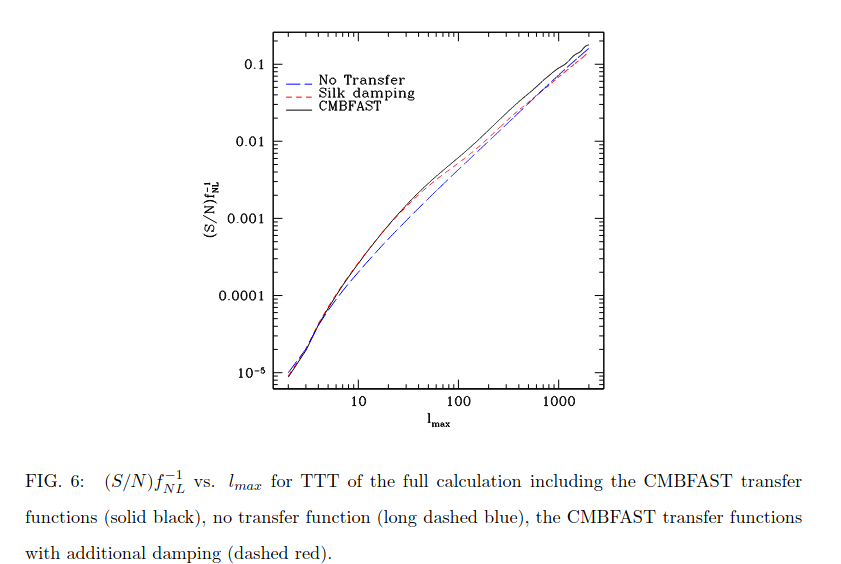

In [174]:
print("Computing S...")
s_avg = compute_S_numba_vec(c_ell, summary=True)
s_avg

Computing S...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   0.63375(39)     0.63375(39)         0.00     1.00
  2   0.63401(45)     0.63386(30)         0.19     0.66
  3   0.63366(38)     0.63379(23)         0.18     0.83
  4   0.63465(52)     0.63393(21)         0.88     0.45
  5   0.63431(38)     0.63402(18)         0.85     0.49
  6   0.63380(37)     0.63397(16)         0.74     0.59
  7   0.63412(43)     0.63399(15)         0.63     0.70
  8   0.63373(36)     0.63395(14)         0.61     0.75
  9   0.63412(44)     0.63397(13)         0.55     0.82
 10   0.63420(42)     0.63399(13)         0.52     0.86



0.00012948321046460357

## Single point test

In [175]:
print("Computing N2...")
N2_avg, integ = compute_N2_numba_vec(c_ell, summary=True)
N2_avg

Computing N2...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   25.0180(98)     25.0180(98)         0.00     1.00
  2   25.0296(99)     25.0238(70)         0.70     0.40
  3   25.0134(94)     25.0201(56)         0.74     0.48
  4   25.018(11)      25.0196(50)         0.51     0.68
  5   25.0154(94)     25.0187(44)         0.42     0.80
  6   25.0106(99)     25.0173(40)         0.45     0.82
  7   25.0212(94)     25.0179(37)         0.40     0.88
  8   25.0199(98)     25.0182(35)         0.34     0.93
  9   25.0166(96)     25.0180(33)         0.30     0.96
 10   25.027(10)      25.0188(31)         0.34     0.96

0.0001294307064578863


0.0001294307064578863

In [176]:
print("Computing N2_lens...")
N2_lens_avg, integ = compute_N2_numba_vec(c_ell, c_ell_lens, summary=True, integ=integ)
N2_lens_avg

Computing N2_lens...
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   25.054(11)      25.054(11)          0.00     1.00
  2   25.0465(94)     25.0497(70)         0.26     0.61
  3   25.0314(91)     25.0429(56)         1.39     0.25
  4   25.0475(95)     25.0441(48)         0.99     0.40
  5   25.046(10)      25.0444(43)         0.74     0.56
  6   25.0454(98)     25.0445(40)         0.60     0.70
  7   25.0510(92)     25.0455(36)         0.57     0.76
  8   25.0501(97)     25.0461(34)         0.51     0.83
  9   25.043(10)      25.0457(32)         0.46     0.88
 10   25.0443(91)     25.0456(30)         0.41     0.93

0.00012956929257578465


0.00012956929257578465

In [177]:
print("Computing delta<N^2>")
delta_N2 = compute_delta_N2_numba_vec(summary=True, nitn=(10, 10))
delta_N2

Computing delta<N^2>
itn   integral        wgt average     chi2/dof        Q
-------------------------------------------------------
  1   0.083556(42)    0.083556(42)        0.00     1.00
  2   0.083484(43)    0.083520(30)        1.46     0.23
  3   0.083522(39)    0.083521(24)        0.73     0.48
  4   0.083574(39)    0.083535(20)        0.93     0.42
  5   0.083600(45)    0.083546(18)        1.13     0.34
  6   0.083557(38)    0.083548(17)        0.92     0.47
  7   0.083584(37)    0.083554(15)        0.89     0.50
  8   0.083484(40)    0.083545(14)        1.14     0.34
  9   0.083581(36)    0.083550(13)        1.10     0.36
 10   0.083548(36)    0.083550(12)        0.98     0.45



9.853706257786301e-08

In [178]:
s_avg = 1
SN_0 = s_avg / np.sqrt(N2_avg)
SN_lens = s_avg / np.sqrt(N2_lens_avg + delta_N2)
ratio = SN_lens / SN_0

print(f"l_max: {LMAX}")
print(f"Average S: {s_avg}")
print(f"Average N^2 (unlensed): {N2_avg}")
print(f"Average N^2 (lensed): {N2_lens_avg}")
print(f"2-point Average: {np.sqrt(N2_avg / N2_lens_avg)}")
print(f"delta<N²> = {delta_N2}")
print(f"S/N (unlensed): {SN_0}")
print(f"S/N (lensed): {SN_lens}")
print(f"ratio: {ratio}")

l_max: 191
Average S: 1
Average N^2 (unlensed): 0.0001294307064578863
Average N^2 (lensed): 0.00012956929257578465
2-point Average: 0.9994650615412733
delta<N²> = 9.853706257786301e-08
S/N (unlensed): 87.89847476886935
S/N (lensed): 87.81806815046139
ratio: 0.9990852330644031


In [179]:
wanted = 1 / 0.5**2 - 1
print(f"need scale factor: {wanted / (1 / ratio**2 - 1)}")

need scale factor: 1637.5122777699098


In [180]:
wanted = 1 / 0.5**2 - 1
lens_ratio = delta_N2 / N2_lens_avg
print(f"need scale factor: {wanted / (lens_ratio)}")

need scale factor: 3944.7885654212682


In [181]:
wanted = 1 / 0.5 - 1
lens_ratio = delta_N2 / N2_lens_avg
print(f"need scale factor: {wanted / (lens_ratio)}")

need scale factor: 1314.9295218070895


In [182]:
def compute_needed_phi_scale(N2_0, N2_lens, delta_N2, R_target):
    """
    Compute the needed lensing potential amplitude scaling factor.

    Parameters:
    -----------
    N2_0 : float
        Unlensed <N²>
    N2_lens : float
        Lensed <N²> at unit amplitude
    delta_N2 : float
        4-point lensing correction at unit amplitude
    R_target : float
        Desired ratio (S/N)_gl / (S/N)_0

    Returns:
    --------
    alpha : float
        Scaling factor for C_ℓ^φφ
    """
    # R² = <N²>_0 / (<N²>_lens + delta<N²>)
    # With scaling: R_target² = <N²>_0 / (α² * (<N²>_lens + delta<N²>))
    # Solving for α²:
    alpha_squared = N2_0 / (R_target**2 * (N2_lens + delta_N2))
    alpha = np.sqrt(alpha_squared)

    return alpha


# Example usage:
R_target = 0.5  # Want 50% of unlensed S/N
alpha = compute_needed_phi_scale(N2_avg, N2_lens_avg, delta_N2, R_target)
print(f"To achieve R = {R_target}, scale C_ℓ^φφ by α² = {alpha**2:.4f}")
print(f"Use phi_scale = {alpha:.4f}")

current_phi_scale = generator.phi_scale
current_ratio = np.sqrt(N2_avg / (N2_lens_avg + delta_N2))

# Desired ratio
desired_ratio = 0.5

# Since lensing terms scale as phi_scale²:
# current_ratio² = N2_0 / (current_phi² * (N2_lens_unit + delta_N2_unit))
# desired_ratio² = N2_0 / (new_phi² * (N2_lens_unit + delta_N2_unit))
# Therefore: new_phi² / current_phi² = current_ratio² / desired_ratio²

scale_factor = current_ratio / desired_ratio
new_phi_scale = current_phi_scale * scale_factor

print(f"Current phi_scale: {current_phi_scale}")
print(f"Current ratio: {current_ratio:.4f}")
print(f"To achieve ratio = {desired_ratio}, use phi_scale = {new_phi_scale:.4f}")

To achieve R = 0.5, scale C_ℓ^φφ by α² = 3.9927
Use phi_scale = 1.9982
Current phi_scale: 1
Current ratio: 0.9991
To achieve ratio = 0.5, use phi_scale = 1.9982


## Plot test

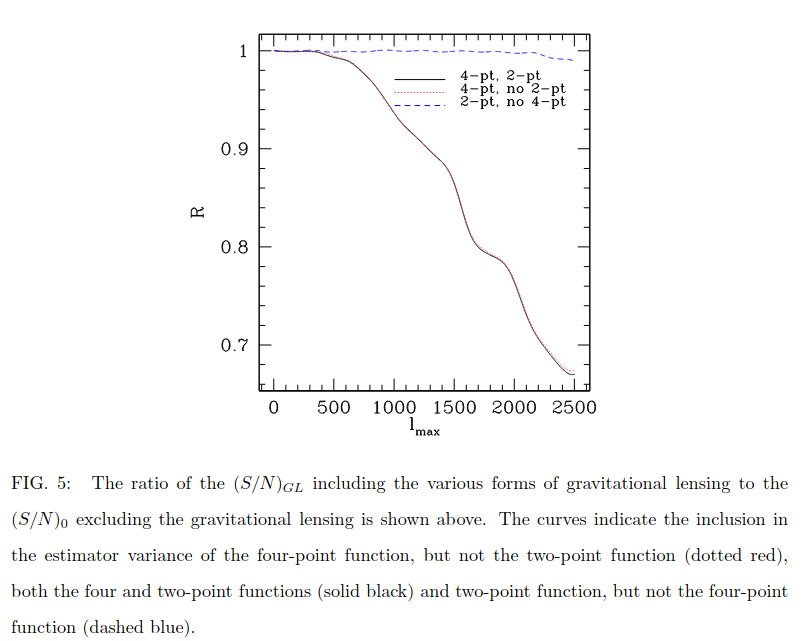

Make the plot, can take a while

In [183]:
# R_ul = []
# R_gl = []
# R_4pt = []
# Ss = []
# N2_0s = []
# N2_gls = []
# deltas = []
# sigma_ul = []
# sigma_gl = []
# valid_ls = []

# ls = np.arange(100, LMAX + 1, 500)
# pbar = tqdm(ls, "data loop", len(ls))
# for lmax in pbar:
#     valid_ls.append(lmax)

#     # pbar.set_description(f"lmax={lmax}: Computing S")
#     S = compute_S_numba_vec(c_ell, lmax=lmax, neval=1e6)
#     Ss.append(S)

#     pbar.set_description(f"lmax={lmax}: Computing N2_0")
#     N2_0, integ = compute_N2_numba_vec(
#         c_ell,
#         lmax=lmax,
#         neval=1e6,
#         # summary=True,
#     )
#     N2_0s.append(N2_0)

#     pbar.set_description(f"lmax={lmax}: Computing N2_lens")
#     N2_lens, integ = compute_N2_numba_vec(
#         c_ell,
#         c_ell_lens,
#         lmax=lmax,
#         neval=1e6,
#         integ=integ,
#         # summary=True,
#     )
#     N2_gls.append(N2_lens)

#     # integ.map.show_grid(100)

#     pbar.set_description(f"lmax={lmax}: Computing delta_N2")
#     delta_N2 = compute_delta_N2_numba_vec(lmax=lmax, neval=1e6, summary=False)
#     deltas.append(delta_N2)

#     R_ul.append(sqrt(N2_0 / N2_lens))
#     R_gl.append(sqrt(N2_0 / (N2_lens + delta_N2)))
#     R_4pt.append(sqrt(N2_lens / (N2_lens + delta_N2)))
#     sigma_ul.append(sqrt((N2_0) / (S * S)))
#     sigma_gl.append(sqrt((N2_lens + delta_N2) / (S * S)))

#     # print(
#     #     f"lmax={lmax}: R={R_ul[-1]:.3f}, R_total={R_gl[-1]:.3f}, R^2={R_gl[-1]**2:.3f}"
#     # )
# # integ.map.show_grid(100)
# pbar.close()

In [184]:
# for label, x in [
#     ["<$N^2$>", N2_0s],
#     ["<$N^2_{lens}$>", N2_gls],
#     [r"|$\delta<N^2>$|", np.array(deltas)],
# ]:
#     plt.semilogy(valid_ls, x, label=label)
# plt.xlabel("lmax")
# plt.legend()
# plt.show()

In [185]:
# true_vals = [[500, 0.99], [1000, 0.94], [1500, 0.86], [2000, 0.76], [2500, 0.67]]
# tx, ty = np.array(true_vals).T

# # for l, r, rt in zip(valid_ls, R_ul, R_gl):
# #     print(
# #         f"lmax={l}: R={r:.3f}, R_total={rt:.3f}, R_sqrt={sqrt(rt):.3f}, R^2={np.square(rt):.3f}"
# #     )

# plt.scatter(tx, ty, s=50, c="k", marker="o", zorder=5, label="true_vals")
# plt.plot(valid_ls, R_ul, "--", color="blue", label="R")
# plt.plot(valid_ls, R_gl, label="$R_{GL}$")
# plt.plot(valid_ls, R_4pt, label="$R_{4pt}$")
# # plt.ylim(0.66, 1.02)
# plt.xlim(0.1, 2600)
# plt.ylabel("R")
# plt.xlabel(r"$\ell_{max}$")
# plt.title(r"$(S/N)_{GL} / (S/N)_{0}$")
# ax = plt.gca()
# ax.tick_params(which="both", top=True, right=True)
# ax.set_yticks(np.arange(0.7, 1.02, 0.1))
# ax.set_xticks(np.arange(0, 2501, 500))
# ax.set_yticks(np.arange(0.66, 1.02, 0.02), minor=True)
# ax.set_xticks(np.arange(0, 2601, 100), minor=True)

# plt.grid(which="both")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [186]:
# # Print ratio comparison between true values and calculated R_gl
# print("Comparison of True Values vs Calculated R_gl:")
# print("=" * 60)
# print(f"{'lmax':<8} {'True_R':<8} {'Calc_R_gl':<10} {'Ratio':<8} {'Diff':<8}")
# print("-" * 60)

# for lmax_true, r_true in true_vals:
#     # Find the closest lmax in valid_ls to the true_val lmax
#     if lmax_true in valid_ls:
#         idx = valid_ls.index(lmax_true)
#         r_calc = R_gl[idx]
#         ratio = r_calc / r_true
#         diff = r_calc - r_true
#         print(
#             f"{lmax_true:<8} {r_true:<8.3f} {r_calc:<10.3f} {ratio:<8.3f} {diff:<8.3f}"
#         )
#     else:
#         print(f"{lmax_true:<8} {r_true:<8.3f} {'N/A':<10} {'N/A':<8} {'N/A':<8}")

# print("-" * 60)
# print("Ratio = Calculated_R_gl / True_R")
# print("Diff = Calculated_R_gl - True_R")
# print("Ideally, Ratio should be close to 1.0 and Diff close to 0.0")

![alt text](ratio_with_grid.png)

#### Second graph test

In [187]:
# plt.semilogy(valid_ls, np.array(sigma_ul) / 2, "--", color="blue", label="sigma_ul")
# plt.semilogy(valid_ls, np.array(sigma_gl) / 2, "--", color="orange", label="sigma_gl")
# ax = plt.gca()
# ax.tick_params(which="both", top=True, right=True)

# # y_ticks = [2.5, 5, 7.5, 10, 12.5, 15, 17.5, 20]
# # ax.set_yticks(y_ticks)
# ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
# ax.set_ylim(y_ticks[0], y_ticks[-1])
# plt.grid()
# plt.tight_layout()
# plt.grid()
# plt.legend()
# plt.show()

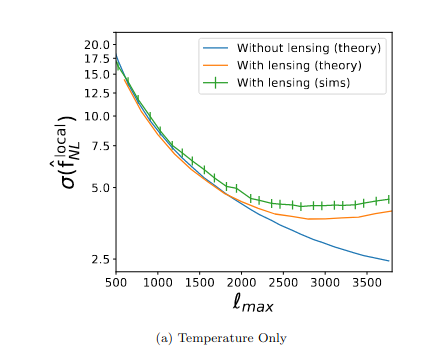